In [ ]:
from PIL import Image
from pathlib import Path
import numpy as np

## Taking a random img

In [17]:
image_path = Path("../data/processed")

image_path_list = list(image_path.glob("*/*/*.jpg"))

random_image_path = random.choice(image_path_list)

random_image_path

WindowsPath('../data/processed/train/City/428.jpg')

## Showing the class of random image

In [18]:
image_class = random_image_path.parent.stem
image_class

'City'

## Showing a image and metadata

Random image path: ..\data\processed\train\City\428.jpg
Image class: City
Image width: 256
Image height: 256


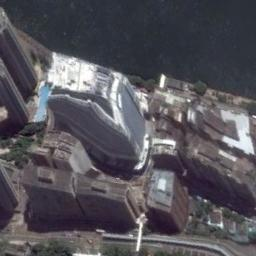

In [19]:
img = Image.open(random_image_path)

print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image width: {img.width}")
print(f"Image height: {img.height}")
img

## Converting image to numpy array

In [20]:
img_as_array = np.asarray(img)
img_as_array


array([[[ 49,  49,  61],
        [ 50,  50,  62],
        [ 53,  53,  65],
        ...,
        [ 43,  47,  56],
        [ 43,  47,  56],
        [ 43,  47,  56]],

       [[ 56,  56,  68],
        [ 56,  56,  68],
        [ 57,  57,  69],
        ...,
        [ 43,  47,  56],
        [ 43,  47,  56],
        [ 43,  47,  56]],

       [[ 48,  48,  58],
        [ 49,  49,  59],
        [ 50,  50,  60],
        ...,
        [ 43,  47,  56],
        [ 43,  47,  56],
        [ 43,  47,  56]],

       ...,

       [[ 86,  86,  84],
        [ 85,  85,  83],
        [ 88,  88,  86],
        ...,
        [113, 109, 110],
        [114, 110, 111],
        [113, 109, 110]],

       [[ 87,  87,  85],
        [ 80,  80,  78],
        [ 79,  79,  77],
        ...,
        [109, 107, 108],
        [112, 110, 111],
        [112, 110, 111]],

       [[ 86,  86,  84],
        [ 75,  75,  73],
        [ 72,  72,  70],
        ...,
        [108, 106, 107],
        [112, 110, 111],
        [113, 111, 112]]

# Transforming data

## Turn our data into tenors 

In [56]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

### Write transform from image

In [75]:
data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5), 
    transforms.RandomVerticalFlip(p=0.5),   
    transforms.RandomRotation(30),
    transforms.ToTensor()
])

In [72]:
data_transform(img)

tensor([[[-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         ...,
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179]],

        [[-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         ...,
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357]],

        [[-1.8044, -1.8044, -1.8044,  ..., -1.8044, -1.8044, -1.8044],
         [-1.8044, -1.8044, -1.8044,  ..., -1

In [76]:
data_transform(img).shape, data_transform(img).dtype

(torch.Size([3, 224, 224]), torch.float32)

# Lets see how our image is looks like

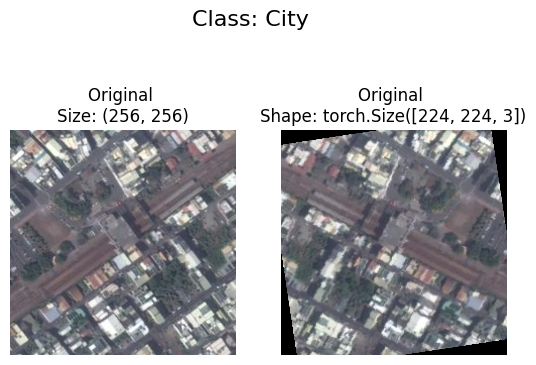

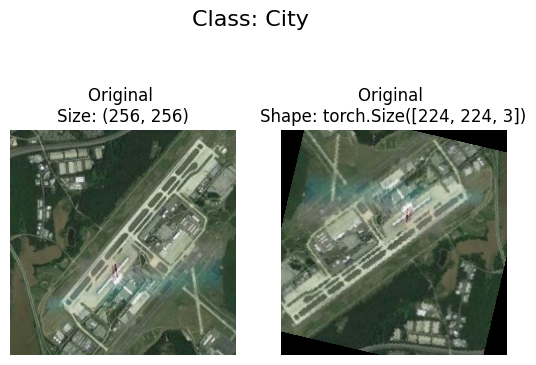

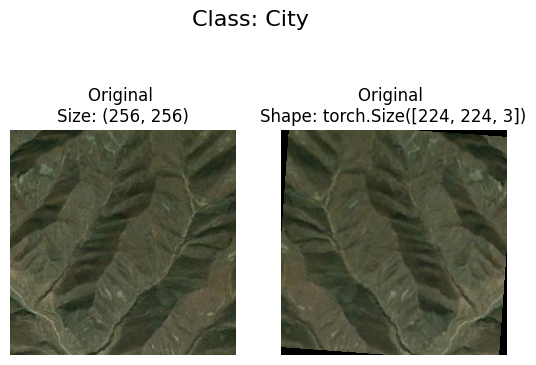

In [79]:
def plot_transformed_images(image_paths: list, transform, n=3):
    """
    Selects random images from a path of images and loads/transforms 
    them then plots the original vs the transformed version
    """
    random_image_paths = random.sample(image_paths, k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(nrows=1, ncols=2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original \nSize: {f.size}")
            ax[0].axis(False)

            # Transform and plot target image
            transformed_image = transform(f).permute(1, 2, 0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Original \nShape: {transformed_image.shape}")
            ax[1].axis(False)

            fig.suptitle(f"Class: {image_class}", fontsize=16)

plot_transformed_images(image_paths=image_path_list, 
                        transform=data_transform,
                        n=3)

